In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

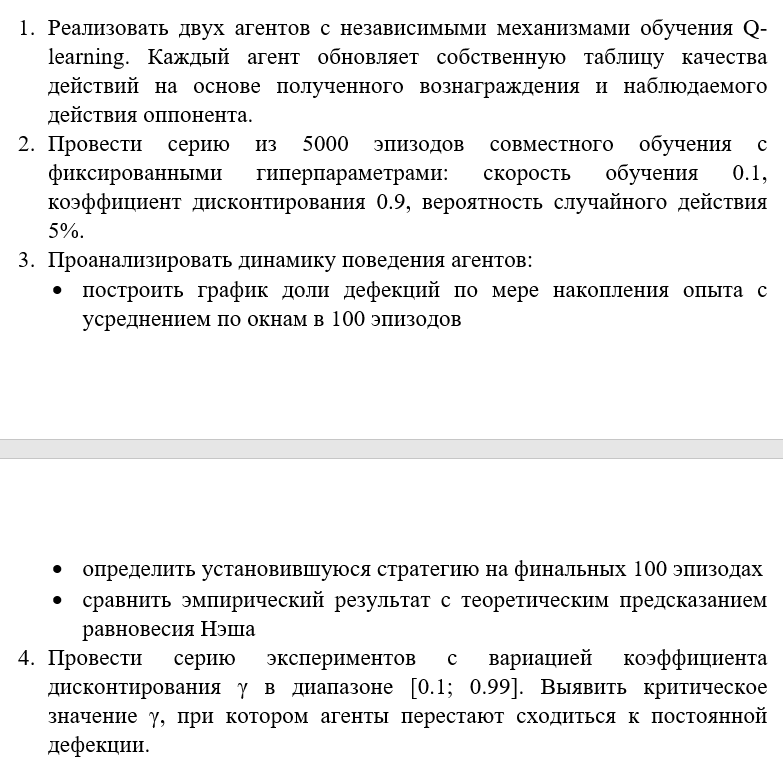

Основные параметры

In [2]:
alpha = 0.1
gamma = 0.95
epsilon = 0.05

episodes = 5000
rounds = 10

Матрица наград (0 - C, 1 - D)

In [3]:
reward = [[[3, 3], [0, 5]], [[5, 0], [1, 1]]]

Q-таблицы

In [4]:
actions = [0, 1]
#-1 - старт, 0 - C, 1 - D
states = [(-1, -1), (0, 0), (0, 1), (1, 0), (1, 1)]

Q1 = {s: {a: 0.0 for a in actions} for s in states}
Q2 = {s: {a: 0.0 for a in actions} for s in states}

Функция выбора действия

In [5]:
def next_action(Q, state):
    if random.random() < epsilon:
        return random.choice(actions)
    return max(Q[state], key=Q[state].get)

Эксперимент

In [6]:
history = []

for i in range(episodes):
    state = (-1, -1)
    defects = 0

    for j in range(rounds):
        action1, action2 = next_action(Q1, state), next_action(Q2, state)
        reward1, reward2 = reward[action1][action2]

        next_state = (action1, action2)

        Q1[state][action1] += alpha * (reward1 + gamma * max(Q1[next_state].values()) - Q1[state][action1])
        Q2[state][action2] += alpha * (reward2 + gamma * max(Q2[next_state].values()) - Q2[state][action2])

        defects += action1 + action2

        state = next_state
    
    history.append(defects / (2 * rounds))

График

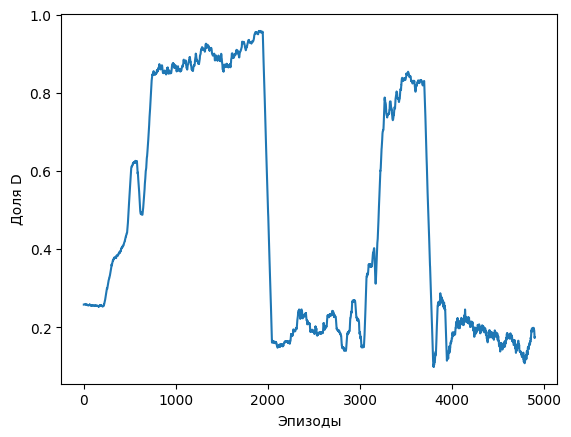

In [7]:
window = 100
smoothed = [np.mean(history[i:i+window]) for i in range(len(history)-window)]

plt.plot(smoothed)
plt.xlabel("Эпизоды")
plt.ylabel("Доля D")
plt.show()